In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd

from matplotlib import rcParams
# Use Arial for all math text
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Helvetica"
plt.rcParams["mathtext.it"] = "Helvetica:italic"
plt.rcParams["mathtext.bf"] = "Helvetica:bold"

# Use Arial for all normal text
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

In [2]:
# line_green  = (46/255, 125/255, 91/255)
# line_violet = (125/255, 63/255, 130/255)
# line_brown = (141/255, 86/255, 58/255)

increase_green  = (111/255, 143/255, 94/255)   # Olive landscape green
decrease_purple = (106/255, 76/255, 125/255)   # Muted aubergine purple

nat_blue   = (74/255, 111/255, 165/255)   # Mediterranean sky blue
res_red    = (200/255, 74/255, 61/255)    # Vermilion / poppy red
all_lake_neutral = (28/255, 24/255, 20/255)
grey_background = (235/255, 233/255, 228/255)

line_black  = (0/255, 0/255, 0/255)

In [3]:
# Load data
df_lake_trend = pd.read_csv(
    "../../Processed_Data/Tahoe_Lake.txt",
    sep=r"\s+",        # whitespace-separated
    comment="#",
    header=None


)
x_tDec = df_lake_trend[0]
y_storage = df_lake_trend[1]
rate = np.gradient(y_storage, x_tDec)

N = 3

x_ds = x_tDec.groupby(x_tDec.index // N).mean()
y_ds = y_storage.groupby(y_storage.index // N).mean()

rate_ds = np.gradient(y_ds, x_ds)


In [4]:
path_storage = "../../Processed_Data/EQ_EF_Storage_Jackknife_Null_depth30km.txt"
df_storage = pd.read_csv(path_storage, sep=r"\t", engine="python")
# Convert to numeric + clean Inf/NaN
for c in df_storage.columns:
    df_storage[c] = pd.to_numeric(df_storage[c], errors="coerce")
df_storage = df_storage.replace([np.inf, -np.inf], np.nan)
df_storage = df_storage[df_storage["dmax_km"] <= 100]


In [5]:
path_storage_rate = "../../Processed_Data/EQ_EF_Storage_Rate_Jackknife_Null_depth30km.txt"
df_storage_rate = pd.read_csv(path_storage_rate, sep=r"\t", engine="python")
# Convert to numeric + clean Inf/NaN
for c in df_storage_rate.columns:
    df_storage_rate[c] = pd.to_numeric(df_storage_rate[c], errors="coerce")
df_storage_rate = df_storage_rate.replace([np.inf, -np.inf], np.nan)
df_storage_rate = df_storage_rate[df_storage_rate["dmax_km"] <= 100]

In [6]:
df_storage.head()

,dmax_km,EF_All,Jack90_All_Low,Jack90_All_High,EF_Reservoir,Jack90_Re_Low,Jack90_Re_High,EF_Natural,Jack90_Na_Low,Jack90_Na_High,Null90_All_Low,Null90_All_High,Null90_Re_Low,Null90_Re_High,Null90_Na_Low,Null90_Na_High
0,20,1.600104,1.300084,2.000141,3.000150,2.333427,4.500246,1.000079,0.714339,1.400104,0.500031,2.000134,0.333350,3.000150,0.375030,2.666862
1,25,1.333411,1.071503,1.636461,2.000080,1.600025,3.000100,1.000076,0.777817,1.285807,0.545486,1.818272,0.400011,2.500107,0.428604,2.200141
2,30,1.444523,1.222287,1.733433,1.571481,1.166720,2.200055,1.363738,1.090987,1.750145,0.592622,1.687593,0.416681,2.400083,0.500035,2.000149
3,35,1.416754,1.217459,1.684307,1.555626,1.222274,2.000111,1.333433,1.071504,1.666779,0.617685,1.591008,0.466689,2.142958,0.545495,1.833470
4,40,1.363714,1.193624,1.555655,1.538521,1.272781,1.900082,1.250091,1.052704,1.500104,0.666704,1.482840,0.526335,1.818257,0.576967,1.687623


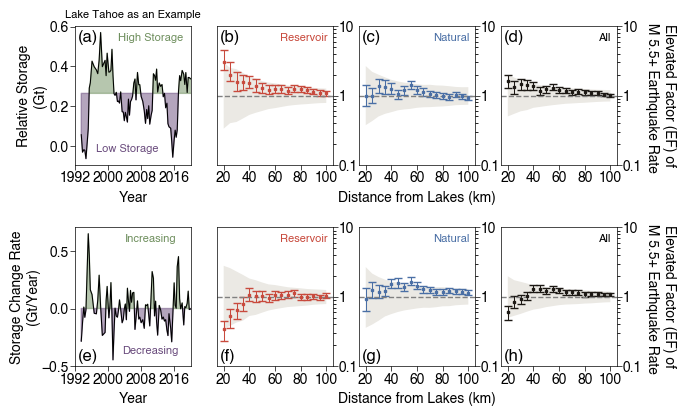

In [8]:
fig = plt.figure(figsize=(6.77, 4))

gs = GridSpec(
    2, 8,
    figure=fig,
    left=0.1, right=0.9,
    bottom=0.1, top=0.95,
    wspace=0.6,
    hspace=0.45
)

# --- ONLY first row (ax3, ax4, ax5) ---
ax0 = fig.add_subplot(gs[0, 0:2])
ax1 = fig.add_subplot(gs[0, 2:4])
ax2 = fig.add_subplot(gs[0, 4:6])
ax3 = fig.add_subplot(gs[0, 6:8])

ax4 = fig.add_subplot(gs[1, 0:2])
ax5 = fig.add_subplot(gs[1, 2:4])
ax6 = fig.add_subplot(gs[1, 4:6])
ax7 = fig.add_subplot(gs[1, 6:8])



# ---------------- ax0 (storage trend) ----------------
ax0.plot(x_ds, y_ds,
                 alpha=1, color=line_black, linewidth = 0.75)

ax0.fill_between(
    x_ds, y_ds.median(), y_ds,
    where=(y_ds >= y_ds.median()),
    interpolate=True,
    alpha=0.5,          # adjust
    color=increase_green     # or another fill color
)

ax0.fill_between(
    x_ds, y_ds.median(), y_ds,
    where=(y_ds < y_ds.median()),
    interpolate=True,
    alpha=0.5,          # adjust
    color=decrease_purple     # or another fill color
)

ax0.text(0.65, 0.95, "High Storage", transform=ax0.transAxes,
         ha="center", va="top", fontsize=8, color=increase_green)

ax0.text(0.45, 0.15, "Low Storage", transform=ax0.transAxes,
         ha="center", va="top", fontsize=8, color=decrease_purple)

ax0.set_xlabel("Year", fontsize=10)
ax0.set_ylabel("Relative Storage\n(Gt)", fontsize=10, labelpad=2)

ax0.set_xticks(np.arange(1995, 2025, 5))
ax0.tick_params(axis='x', labelsize=10, pad = 1)
ax0.tick_params(axis='y', labelsize=10, pad = 1)
# ax0.set_yticks(np.arange(-1,2, 1))
ax0.set_xlim(1992, 2020)
ax0.set_xticks(np.arange(1992,2020, 8))
# ax0.set_ylim(-1, 1)
ax0.set_title('Lake Tahoe as an Example', fontsize = 8)


# ---------------- ax4 (storage rate trend) ----------------
ax4.plot(x_ds, rate_ds,
                 alpha=1, color=line_black, linewidth = 0.75)

ax4.fill_between(
    x_ds, 0, rate_ds,
    where=(rate_ds >= 0),
    interpolate=True,
    alpha=0.5,          # adjust
    color=increase_green     # or another fill color
)

ax4.fill_between(
    x_ds, 0, rate_ds,
    where=(rate_ds < 0),
    interpolate=True,
    alpha=0.5,          # adjust
    color=decrease_purple     # or another fill color
)

ax4.text(0.65, 0.95, "Increasing", transform=ax4.transAxes,
         ha="center", va="top", fontsize=8, color=increase_green)

ax4.text(0.65, 0.15, "Decreasing", transform=ax4.transAxes,
         ha="center", va="top", fontsize=8, color=decrease_purple)

ax4.set_xlabel("Year", fontsize=10)
ax4.set_ylabel("Storage Change Rate\n(Gt/Year)", fontsize=10, labelpad=1)

ax4.set_xticks(np.arange(1995, 2025, 5))
ax4.tick_params(axis='x', labelsize=10, pad = 1)
ax4.tick_params(axis='y', labelsize=10, pad = 1)
# ax4.set_yticks(np.arange(-1,2, 1))
ax4.set_xlim(1992, 2020)
ax4.set_xticks(np.arange(1992,2020, 8))
# ax4.set_ylim(-1, 1)

# ---------------- ax1 (Reservoir) ----------------
ax1.fill_between(df_storage["dmax_km"], df_storage["Null90_Re_Low"], df_storage["Null90_Re_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax1_yerr = [
    df_storage["EF_Reservoir"] - df_storage["Jack90_Re_Low"],
    df_storage["Jack90_Re_High"] - df_storage["EF_Reservoir"]
]

ax1.errorbar(
    x=df_storage["dmax_km"], y=df_storage["EF_Reservoir"], yerr=ax1_yerr,
    alpha=1, color=res_red, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=res_red, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax1.axhline(1, linestyle="--", linewidth=1, color="grey")
ax1.text(0.75, 0.95, "Reservoir", transform=ax1.transAxes,
         ha="center", va="top", fontsize=8, color=res_red)

# ax1.set_xlabel("Distance from Lakes (km)")
ax1.tick_params(axis="x", labelsize=10, pad=1)
ax1.tick_params(axis="y", labelsize=10, pad=1)
ax1.set_xticks(np.arange(20, 101, 20))
ax1.set_xlim(15, 105)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")
ax1.set_ylim(0.1,10)
ax1.set_yscale('log')
ax1.set_yticks(10**(np.linspace(-1,1,3)))
ax1.set_yticklabels(['0.1','1','10'])

# ---------------- ax2 (Natural) ----------------
ax2.fill_between(df_storage["dmax_km"], df_storage["Null90_Na_Low"], df_storage["Null90_Na_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax2_yerr = [
    df_storage["EF_Natural"] - df_storage["Jack90_Na_Low"],
    df_storage["Jack90_Na_High"] - df_storage["EF_Natural"]
]

ax2.errorbar(
    x=df_storage["dmax_km"], y=df_storage["EF_Natural"], yerr=ax2_yerr,
    alpha=1, color=nat_blue, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=nat_blue, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax2.axhline(1, linestyle="--", linewidth=1, color="grey")
ax2.text(0.8, 0.95, "Natural", transform=ax2.transAxes,
         ha="center", va="top", fontsize=8, color=nat_blue)


ax2.set_xlabel("Distance from Lakes (km)")
ax2.tick_params(axis="x", labelsize=10, pad=1)
ax2.tick_params(axis="y", labelsize=10, pad=1)
ax2.set_xticks(np.arange(20, 101, 20))
ax2.set_xlim(15, 105)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylim(0.1,10)
ax2.set_yscale('log')
ax2.set_yticks(10**(np.linspace(-1,1,3)))
ax2.set_yticklabels(['0.1','1','10'])

# ---------------- ax3 (ALL) ----------------
ax3.fill_between(df_storage["dmax_km"], df_storage["Null90_All_Low"], df_storage["Null90_All_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax3_yerr = [
    df_storage["EF_All"] - df_storage["Jack90_All_Low"],
    df_storage["Jack90_All_High"] - df_storage["EF_All"]
]

ax3.errorbar(
    x=df_storage["dmax_km"], y=df_storage["EF_All"], yerr=ax3_yerr,
    alpha=1, color=all_lake_neutral, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=all_lake_neutral, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax3.axhline(1, linestyle="--", linewidth=1, color="grey")
ax3.text(0.9, 0.95, "All", transform=ax3.transAxes,
         ha="center", va="top", fontsize=8, color=line_black)

ax3.tick_params(axis="x", labelsize=10, pad=1)
ax3.tick_params(axis="y", labelsize=10, pad=1)
ax3.set_xticks(np.arange(20, 101, 20))

ax3.set_xlim(15, 105)
# ax3.set_xlabel("Distance from Lakes (km)")
ax3.set_ylabel("Elevated Factor (EF) of\n M 5.5+ Earthquake Rate", rotation=-90, labelpad=24)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.set_ylim(0.1,10)
ax3.set_yscale('log')
ax3.set_yticks(10**(np.linspace(-1,1,3)))
ax3.set_yticklabels(['0.1','1','10'])


# ---------------- ax5 (Reservoir) ----------------
ax5.fill_between(df_storage_rate["dmax_km"], df_storage_rate["Null90_Re_Low"], df_storage_rate["Null90_Re_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax5_yerr = [
    df_storage_rate["EF_Reservoir"] - df_storage_rate["Jack90_Re_Low"],
    df_storage_rate["Jack90_Re_High"] - df_storage_rate["EF_Reservoir"]
]

ax5.errorbar(
    x=df_storage_rate["dmax_km"], y=df_storage_rate["EF_Reservoir"], yerr=ax5_yerr,
    alpha=1, color=res_red, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=res_red, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax5.axhline(1, linestyle="--", linewidth=1, color="grey")
ax5.text(0.75, 0.95, "Reservoir", transform=ax5.transAxes,
         ha="center", va="top", fontsize=8, color=res_red)

# ax5.set_xlabel("Distance from Lakes (km)")
ax5.tick_params(axis="x", labelsize=10, pad=1)
ax5.tick_params(axis="y", labelsize=10, pad=1)
ax5.set_xticks(np.arange(20, 101, 20))
ax5.set_xlim(15, 105)
ax5.yaxis.tick_right()
ax5.yaxis.set_label_position("right")
ax5.set_ylim(0.1,10)
ax5.set_yscale('log')
ax5.set_yticks(10**(np.linspace(-1,1,3)))
ax5.set_yticklabels(['0.1','1','10'])


# ---------------- ax6 (Natural) ----------------
ax6.fill_between(df_storage_rate["dmax_km"], df_storage_rate["Null90_Na_Low"], df_storage_rate["Null90_Na_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax6_yerr = [
    df_storage_rate["EF_Natural"] - df_storage_rate["Jack90_Na_Low"],
    df_storage_rate["Jack90_Na_High"] - df_storage_rate["EF_Natural"]
]

ax6.errorbar(
    x=df_storage_rate["dmax_km"], y=df_storage_rate["EF_Natural"], yerr=ax6_yerr,
    alpha=1, color=nat_blue, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=nat_blue, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax6.axhline(1, linestyle="--", linewidth=1, color="grey")
ax6.text(0.8, 0.95, "Natural", transform=ax6.transAxes,
         ha="center", va="top", fontsize=8, color=nat_blue)


ax6.set_xlabel("Distance from Lakes (km)")
ax6.tick_params(axis="x", labelsize=10, pad=1)
ax6.tick_params(axis="y", labelsize=10, pad=1)
ax6.set_xticks(np.arange(20, 101, 20))
ax6.set_xlim(15, 105)
ax6.yaxis.tick_right()
ax6.yaxis.set_label_position("right")
ax6.set_ylim(0.1,10)
ax6.set_yscale('log')
ax6.set_yticks(10**(np.linspace(-1,1,3)))
ax6.set_yticklabels(['0.1','1','10'])

# ---------------- ax7 (ALL) ----------------
ax7.fill_between(df_storage_rate["dmax_km"], df_storage_rate["Null90_All_Low"], df_storage_rate["Null90_All_High"],
                 alpha=1, color=grey_background, edgecolor="none")

ax7_yerr = [
    df_storage_rate["EF_All"] - df_storage_rate["Jack90_All_Low"],
    df_storage_rate["Jack90_All_High"] - df_storage_rate["EF_All"]
]

ax7.errorbar(
    x=df_storage_rate["dmax_km"], y=df_storage_rate["EF_All"], yerr=ax7_yerr,
    alpha=1, color=all_lake_neutral, linestyle="none",
    marker="s", markersize=2,
    markerfacecolor=all_lake_neutral, markeredgewidth=1,
    elinewidth=0.75, capsize=3, capthick=0.75
)

ax7.axhline(1, linestyle="--", linewidth=1, color="grey")
ax7.text(0.9, 0.95, "All", transform=ax7.transAxes,
         ha="center", va="top", fontsize=8, color=line_black)

ax7.tick_params(axis="x", labelsize=10, pad=1)
ax7.tick_params(axis="y", labelsize=10, pad=1)
ax7.set_xticks(np.arange(20, 101, 20))
ax7.set_xlim(15, 105)
# ax7.set_xlabel("Distance from Lakes (km)")
ax7.set_ylabel("Elevated Factor (EF) of\n M 5.5+ Earthquake Rate", rotation=-90, labelpad=24)
ax7.yaxis.tick_right()
ax7.yaxis.set_label_position("right")
ax7.set_ylim(0.1,10)
ax7.set_yscale('log')
ax7.set_yticks(10**(np.linspace(-1,1,3)))
ax7.set_yticklabels(['0.1','1','10'])

# Spine styling (only these axes)
for ax in [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

### Frame Style ###
for ax, label in [(ax0, '(a)'), (ax1, '(b)'), (ax2, '(c)'), (ax3, '(d)')]:
    ax.text(0.025, 0.975, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

for ax, label in [(ax4, '(e)'), (ax5, '(f)'), (ax6, '(g)'), (ax7, '(h)')]:
    ax.text(0.025, 0.125, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

plt.savefig("fig3.pdf", dpi=300)
plt.savefig("fig3.png", dpi=300)
plt.show()